In [ ]:
import yfinance as yf
nifty50 = yf.Ticker("^NSEI")
nifty50 = nifty50.history(period='max')
nifty50

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2007-09-17 00:00:00+05:30,4518.450195,4549.049805,4482.850098,4494.649902,0,0.0,0.0
2007-09-18 00:00:00+05:30,4494.100098,4551.799805,4481.549805,4546.200195,0,0.0,0.0
2007-09-19 00:00:00+05:30,4550.250000,4739.000000,4550.250000,4732.350098,0,0.0,0.0
2007-09-20 00:00:00+05:30,4734.850098,4760.850098,4721.149902,4747.549805,0,0.0,0.0
2007-09-21 00:00:00+05:30,4752.950195,4855.700195,4733.700195,4837.549805,0,0.0,0.0
...,...,...,...,...,...,...,...
2026-05-12 00:00:00+05:30,23722.599609,23757.550781,23348.400391,23379.550781,447500,0.0,0.0
2026-05-13 00:00:00+05:30,23362.449219,23582.949219,23262.550781,23412.599609,415400,0.0,0.0
2026-05-14 00:00:00+05:30,23530.250000,23777.199219,23426.550781,23689.599609,428700,0.0,0.0


Pur first step involves importing yfinance to get information about the specific day when market was open.

We have chosen Nifty50, with ticker NSEI.

We want information ranging from the day the data was archived electronically till date, therefore we set the time period history at "MAX".

The table includes the date, "Open", "High", "Low", "Close", "Volume","Dividends" and Stock Splits".

In [ ]:
nifty50.index

DatetimeIndex(['2007-09-17 00:00:00+05:30', '2007-09-18 00:00:00+05:30',
               '2007-09-19 00:00:00+05:30', '2007-09-20 00:00:00+05:30',
               '2007-09-21 00:00:00+05:30', '2007-09-24 00:00:00+05:30',
               '2007-09-25 00:00:00+05:30', '2007-09-26 00:00:00+05:30',
               '2007-09-27 00:00:00+05:30', '2007-09-28 00:00:00+05:30',
               ...
               '2026-05-05 00:00:00+05:30', '2026-05-06 00:00:00+05:30',
               '2026-05-07 00:00:00+05:30', '2026-05-08 00:00:00+05:30',
               '2026-05-11 00:00:00+05:30', '2026-05-12 00:00:00+05:30',
               '2026-05-13 00:00:00+05:30', '2026-05-14 00:00:00+05:30',
               '2026-05-15 00:00:00+05:30', '2026-05-18 00:00:00+05:30'],
              dtype='datetime64[ns, Asia/Kolkata]', name='Date', length=4577, freq=None)

The Indian markets' historical data, ranging from 2007 to 2025, is considered relatively recent and reliable due to the transition to electronic data collection and storage, which has minimized errors and inconsistencies. To ensure data integrity, it is essential to verify the data source and its credibility, conduct a preliminary check for missing values or inconsistencies, and cross-validate the data with other reputable sources, if available. By adopting this rigorous approach, we can further enhance our confidence in the accuracy and reliability of the data.

<Axes: xlabel='Date'>

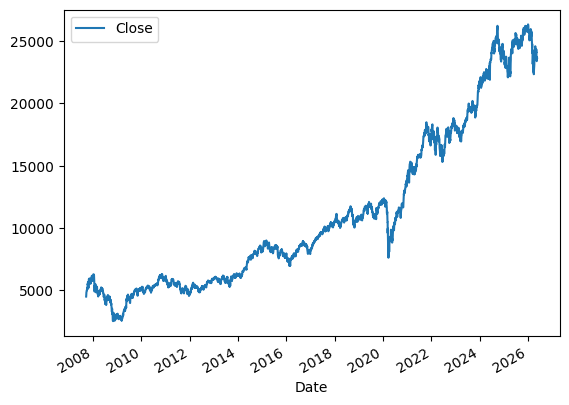

In [ ]:
nifty50.plot.line(y="Close", use_index=True)

In [ ]:
#Remove Dividends and stock splits as we will not be utilizing those data points
del nifty50['Dividends']
del nifty50['Stock Splits']

ML is great at predicting the prices, and you can be extremely accurate at predicting the absolute price of a stock,
but it will be of no use, if you can't observe or analyze the directionality of the stock i.e., when the stock price will go up and when it will go down. In order to achieve this objective, our model should be able to detect days when market closed, whether it was porfitable to buy the stock on those days and after a buy those stock prices went up.

TL:DR
1. Detect days when the market closed
2. Identify profitable buy days
3. Analyze post-buy stock price movements to confirm upward trends

In [ ]:
#adding Tomorrow's column, where the data is shift a day back using the pandas shift method.
nifty50["Tomorrow"] = nifty50["Close"].shift(-1)
nifty50

,Open,High,Low,Close,Volume,Tomorrow
Date,,,,,,
2007-09-17 00:00:00+05:30,4518.450195,4549.049805,4482.850098,4494.649902,0,4546.200195
2007-09-18 00:00:00+05:30,4494.100098,4551.799805,4481.549805,4546.200195,0,4732.350098
2007-09-19 00:00:00+05:30,4550.250000,4739.000000,4550.250000,4732.350098,0,4747.549805
2007-09-20 00:00:00+05:30,4734.850098,4760.850098,4721.149902,4747.549805,0,4837.549805
2007-09-21 00:00:00+05:30,4752.950195,4855.700195,4733.700195,4837.549805,0,4932.200195
...,...,...,...,...,...,...
2026-05-12 00:00:00+05:30,23722.599609,23757.550781,23348.400391,23379.550781,447500,23412.599609
2026-05-13 00:00:00+05:30,23362.449219,23582.949219,23262.550781,23412.599609,415400,23689.599609
2026-05-14 00:00:00+05:30,23530.250000,23777.199219,23426.550781,23689.599609,428700,23643.500000


In [ ]:
nifty50["Target"] = (nifty50["Tomorrow"] > nifty50["Close"]).astype(int)
nifty50
#binary indication whether the target was achieved(1) or not(0)

,Open,High,Low,Close,Volume,Tomorrow,Target
Date,,,,,,,
2007-09-17 00:00:00+05:30,4518.450195,4549.049805,4482.850098,4494.649902,0,4546.200195,1
2007-09-18 00:00:00+05:30,4494.100098,4551.799805,4481.549805,4546.200195,0,4732.350098,1
2007-09-19 00:00:00+05:30,4550.250000,4739.000000,4550.250000,4732.350098,0,4747.549805,1
2007-09-20 00:00:00+05:30,4734.850098,4760.850098,4721.149902,4747.549805,0,4837.549805,1
2007-09-21 00:00:00+05:30,4752.950195,4855.700195,4733.700195,4837.549805,0,4932.200195,1
...,...,...,...,...,...,...,...
2026-05-12 00:00:00+05:30,23722.599609,23757.550781,23348.400391,23379.550781,447500,23412.599609,1
2026-05-13 00:00:00+05:30,23362.449219,23582.949219,23262.550781,23412.599609,415400,23689.599609,1
2026-05-14 00:00:00+05:30,23530.250000,23777.199219,23426.550781,23689.599609,428700,23643.500000,0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, min_samples_split=100, random_state=1)

train = nifty50.iloc[:-100]
test = nifty50.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]
model.fit(train[predictors], train["Target"])

RandomForestClassifier(min_samples_split=100, random_state=1)

In [ ]:
nifty50['Volume'].dtype

dtype('int64')

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score

preds = model.predict(test[predictors])
preds = pd.Series(preds, index=test.index)
precision_score(test["Target"], preds)

0.52

<Axes: xlabel='Date'>

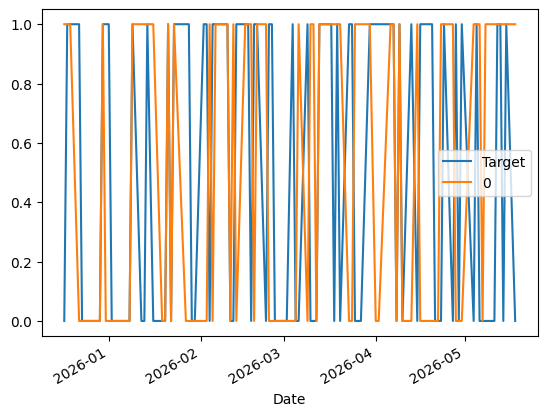

In [ ]:
combined = pd.concat([test["Target"], preds], axis=1)
combined.plot()

In [ ]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [ ]:
def backtest(data, model, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[0:i].copy()
        test = data.iloc[i:(i+step)].copy()
        predictions = predict(train, test, predictors, model)
        all_predictions.append(predictions)

    return pd.concat(all_predictions)

In [ ]:
predictions = backtest(nifty50, model, predictors)

In [ ]:
predictions["Predictions"].value_counts()

,count
Predictions,
1,1149
0,928


In [ ]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5308964316797214

In [ ]:
predictions["Target"].value_counts() / predictions.shape[0]

,count
Target,
1,0.540684
0,0.459316


In [ ]:
horizons = [2,5,60,250,1000]
new_predictors = []

for horizon in horizons:
    rolling_averages = nifty50.rolling(horizon).mean()

    ratio_column = f"Close_Ratio_{horizon}"
    nifty50[ratio_column] = nifty50["Close"] / rolling_averages["Close"]

    trend_column = f"Trend_{horizon}"
    nifty50[trend_column] = nifty50.shift(1).rolling(horizon).sum()["Target"]

    new_predictors+= [ratio_column, trend_column]

In [ ]:
nifty50 = nifty50.dropna(subset=nifty50.columns[nifty50.columns != "Tomorrow"])
nifty50

,Open,High,Low,Close,Volume,Tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
2011-10-13 00:00:00+05:30,5130.799805,5136.950195,5067.649902,5077.850098,0,5132.299805,1,0.997883,1.0,1.014789,3.0,0.992330,23.0,0.911365,111.0,1.042939,510.0
2011-10-14 00:00:00+05:30,5057.350098,5141.399902,5056.600098,5132.299805,0,5118.250000,0,1.005333,1.0,1.015754,3.0,1.004393,24.0,0.921801,111.0,1.053995,510.0
2011-10-17 00:00:00+05:30,5156.200195,5160.200195,5084.500000,5118.250000,0,5037.500000,0,0.998629,1.0,1.007444,2.0,1.003264,23.0,0.919921,111.0,1.051026,509.0
2011-10-18 00:00:00+05:30,5049.450195,5057.500000,5011.049805,5037.500000,0,5139.149902,1,0.992049,0.0,0.989091,2.0,0.989147,23.0,0.906187,110.0,1.034383,508.0
2011-10-19 00:00:00+05:30,5080.450195,5148.049805,5075.299805,5139.149902,0,5091.899902,0,1.009989,1.0,1.007477,2.0,1.010438,24.0,0.925163,111.0,1.055190,508.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-05-12 00:00:00+05:30,23722.599609,23757.550781,23348.400391,23379.550781,447500,23412.599609,1,0.990755,0.0,0.973911,1.0,0.965592,31.0,0.933478,127.0,1.080207,533.0
2026-05-13 00:00:00+05:30,23362.449219,23582.949219,23262.550781,23412.599609,415400,23689.599609,1,1.000706,1.0,0.982808,1.0,0.968639,31.0,0.934926,128.0,1.081422,534.0
2026-05-14 00:00:00+05:30,23530.250000,23777.199219,23426.550781,23689.599609,428700,23643.500000,0,1.005881,2.0,0.999783,2.0,0.981632,31.0,0.946035,129.0,1.093876,535.0


In [ ]:
model = RandomForestClassifier(n_estimators=200, min_samples_split=50, random_state=1)

In [ ]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds >=.6] = 1
    preds[preds <.6] = 0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [ ]:
predictions = backtest(nifty50, model, new_predictors)

In [ ]:
predictions["Predictions"].value_counts()

,count
Predictions,
0.0,956
1.0,121


In [ ]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5537190082644629